In [53]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "college_sleep_and_gpa.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "kylefengkfeng209/sleep-vs-gpa-in-college",
    file_path,
)

file_path2 = "study_cohort_reference.csv"
df2 = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "kylefengkfeng209/sleep-vs-gpa-in-college",
    file_path2,
)

# print("First 5 records:", df.head())
print(df.columns)
print(df2.columns)

100%|██████████| 288/288 [00:00<00:00, 237kB/s]

Index(['student_id', 'study', 'university', 'semester', 'cohort_code',
       'gender', 'first_generation', 'underrepresented', 'avg_sleep_minutes',
       'avg_sleep_hours', 'daytime_sleep_minutes', 'sleep_midpoint_minutes',
       'bedtime_variability', 'nights_tracked_fraction', 'prior_gpa',
       'term_gpa', 'gpa_change', 'term_units', 'term_load_z', 'under_6h_sleep',
       'sleep_bracket', 'sleep_midpoint_clock'],
      dtype='str')
Index(['study', 'university', 'semester', 'cohort_code', 'n_students'], dtype='str')


In [2]:
# %pip uninstall -y kagglehub kagglesdk
# %pip install --upgrade kagglehub[pandas-datasets]

In [11]:
display(df2.head(10))

,study,university,semester,cohort_code,n_students
0,1,Carnegie Mellon University,Spring 2018,lac2,77
1,2,University of Washington,Spring 2018,uw1,140
2,3,University of Washington,Spring 2019,uw2,139
3,4,University of Notre Dame,Spring 2016,nh,147
4,5,Carnegie Mellon University,Spring 2017,lac1,131


In [9]:
print(df.shape)
print(df2.shape)

(634, 22)
(5, 5)


In [13]:
print(df2['n_students'].sum())

634


# colleg_sleep_and_gpa data exploration

In [19]:
print(df.shape)
print(df.info())

(634, 22)
<class 'pandas.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               634 non-null    int64  
 1   study                    634 non-null    int64  
 2   university               634 non-null    str    
 3   semester                 634 non-null    str    
 4   cohort_code              634 non-null    str    
 5   gender                   631 non-null    str    
 6   first_generation         630 non-null    float64
 7   underrepresented         633 non-null    float64
 8   avg_sleep_minutes        634 non-null    float64
 9   avg_sleep_hours          634 non-null    float64
 10  daytime_sleep_minutes    634 non-null    float64
 11  sleep_midpoint_minutes   634 non-null    float64
 12  bedtime_variability      634 non-null    float64
 13  nights_tracked_fraction  634 non-null    float64
 14  prior_gpa                63

+ this data is clean - no null value

In [22]:
display(df)

,student_id,study,university,semester,cohort_code,gender,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,...,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep,sleep_bracket,sleep_midpoint_clock
0,293,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,370.0,6.17,...,0.0500,0.931,4.00,3.76,-0.24,49.0,0.112,0,6-6.5h,07:20
1,294,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,406.8,6.78,...,0.0476,0.862,4.00,3.55,-0.45,49.0,0.112,0,6.5-7h,05:00
2,297,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,253.8,4.23,...,0.1639,0.586,3.00,3.59,0.59,46.0,-0.604,1,<5.5h,05:38
3,303,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,0.0,411.9,6.86,...,0.7854,0.931,3.80,3.46,-0.34,39.0,-2.275,0,6.5-7h,07:52
4,304,1,Carnegie Mellon University,Spring 2018,lac2,Female,0.0,1.0,408.1,6.80,...,0.1538,0.931,3.17,3.50,0.33,39.0,-2.275,0,6.5-7h,04:54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629,347,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,445.6,7.43,...,0.0950,1.000,3.74,3.74,0.00,46.0,-0.663,0,7-7.5h,04:13
630,349,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,430.8,7.18,...,0.1070,0.276,3.44,3.61,0.17,49.0,-0.139,0,7-7.5h,04:51
631,353,5,Carnegie Mellon University,Spring 2017,lac1,Female,0.0,0.0,360.9,6.01,...,0.0608,1.000,3.62,3.81,0.19,54.0,0.735,0,6-6.5h,06:33
632,356,5,Carnegie Mellon University,Spring 2017,lac1,Male,0.0,0.0,303.8,5.06,...,0.1568,0.276,3.22,1.38,-1.84,48.0,-0.313,1,<5.5h,06:11


In [20]:
df.describe()

,student_id,study,first_generation,underrepresented,avg_sleep_minutes,avg_sleep_hours,daytime_sleep_minutes,sleep_midpoint_minutes,bedtime_variability,nights_tracked_fraction,prior_gpa,term_gpa,gpa_change,term_units,term_load_z,under_6h_sleep
count,634.000000,634.000000,630.000000,633.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,487.000000,487.000000,634.000000
mean,13005.892744,3.181388,0.166667,0.187994,397.324763,6.622098,41.165615,398.678707,0.451687,0.867478,3.465584,3.449587,-0.015997,29.392197,-0.000057,0.208202
std,26496.593477,1.317125,0.377213,0.391016,50.855641,0.847741,27.388294,72.712017,1.393631,0.178999,0.437578,0.500463,0.403109,17.642780,1.000017,0.406343
min,1.000000,1.000000,0.000000,0.000000,194.800000,3.250000,2.300000,247.100000,0.004500,0.214000,1.210000,0.350000,-1.877000,5.000000,-3.983000,0.000000
25%,178.000000,2.000000,0.000000,0.000000,366.950000,6.112500,23.100000,345.175000,0.074700,0.821000,3.232250,3.233000,-0.189500,15.000000,-0.551000,0.000000
50%,358.500000,3.000000,0.000000,0.000000,400.350000,6.675000,35.000000,388.250000,0.135000,0.932000,3.558000,3.556000,0.000000,17.000000,0.041000,0.000000
75%,592.750000,4.000000,0.000000,0.000000,430.100000,7.170000,51.250000,437.625000,0.291700,1.000000,3.789500,3.810000,0.193750,48.000000,0.560000,0.000000
max,99978.000000,5.000000,2.000000,1.000000,587.700000,9.790000,292.300000,724.700000,20.849200,1.000000,4.000000,4.000000,1.332000,73.000000,4.055000,1.000000


In [24]:
df.groupby('gender')[['term_gpa', 'avg_sleep_hours']].mean()

,term_gpa,avg_sleep_hours
gender,,
Female,3.449459,6.651576
Male,3.451738,6.582662


In [25]:
df.groupby('university')[['term_gpa', 'avg_sleep_hours']].mean()

,term_gpa,avg_sleep_hours
university,,
Carnegie Mellon University,3.353029,6.448173
University of Notre Dame,3.664544,6.419320
University of Washington,3.408315,6.858602


In [26]:
df.groupby(['university', 'gender'])[['term_gpa', 'avg_sleep_hours']].mean()

term_gpa  avg_sleep_hours
university                 gender                           
Carnegie Mellon University Female  3.354435         6.426452
                           Male    3.346951         6.499512
University of Notre Dame   Female  3.656831         6.452113
                           Male    3.671750         6.388684
University of Washington   Female  3.432462         6.894798
                           Male    3.374324         6.788000

<function matplotlib.pyplot.show(close=None, block=None)>

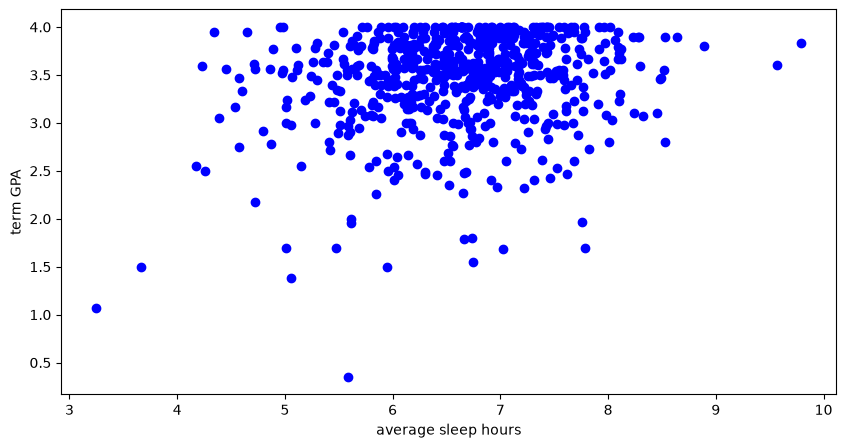

In [51]:
plt.figure(figsize=(10, 5))
plt.scatter(df['avg_sleep_hours'], df['term_gpa'], color = "blue")
plt.xlabel("average sleep hours")
plt.ylabel("term GPA")
plt.show

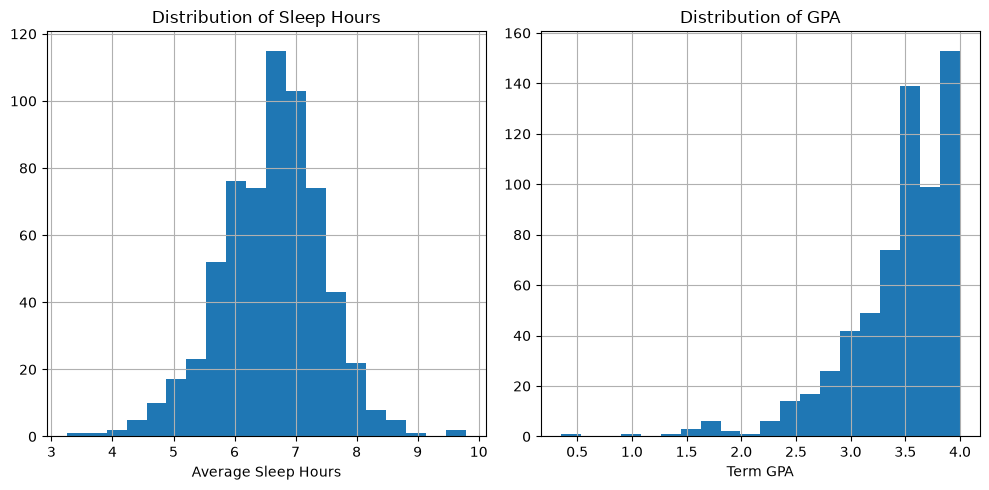

In [43]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df['avg_sleep_hours'].hist(bins=20)
plt.xlabel('Average Sleep Hours')
plt.title('Distribution of Sleep Hours')

plt.subplot(1, 2, 2)
df['term_gpa'].hist(bins=20)
plt.xlabel('Term GPA')
plt.title('Distribution of GPA')

plt.tight_layout()
plt.show()

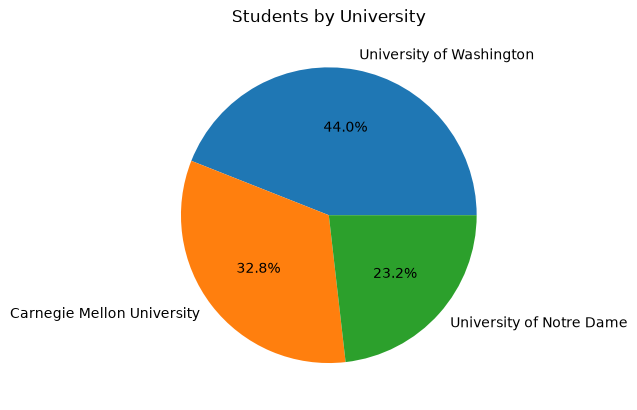

In [47]:
df['university'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Students by University')
plt.ylabel('')  # removes the default y-axis label pandas adds
plt.show()

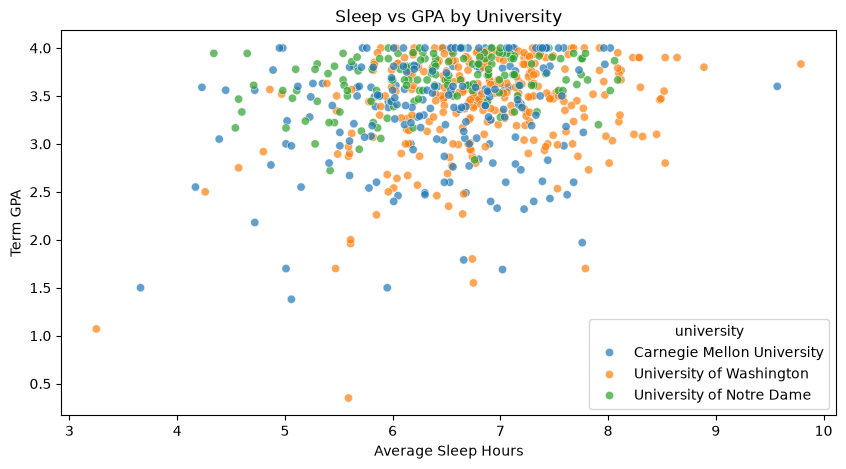

In [55]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='avg_sleep_hours', y='term_gpa', hue='university', alpha=0.7)
plt.xlabel('Average Sleep Hours')
plt.ylabel('Term GPA')
plt.title('Sleep vs GPA by University')
plt.show()

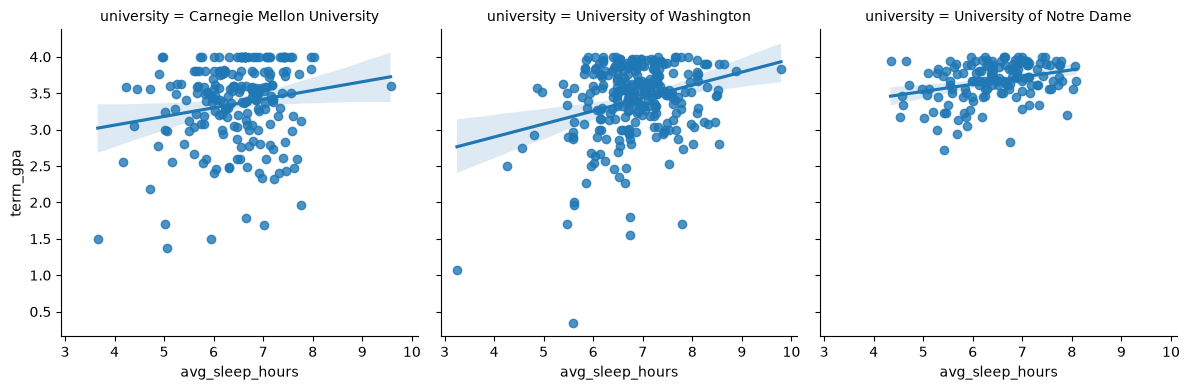

In [56]:
sns.lmplot(data=df, x='avg_sleep_hours', y='term_gpa', col='university', height=4)
plt.show()

In [86]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_error

# Select features - numeric sleep-related columns, plus prior_gpa as a baseline
features = ['avg_sleep_hours', 'sleep_midpoint_minutes', 'bedtime_variability',
            'daytime_sleep_minutes', 'nights_tracked_fraction', 'prior_gpa', 'term_units']
target = 'term_gpa'

# Drop rows with missing values in these columns
model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55)

In [88]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [89]:
lasso = Lasso(alpha=0.05)  # alpha controls regularization strength
lasso.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.05
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [90]:
y_pred = lasso.predict(X_test_scaled)

print("R^2 score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))
# print("Accuracy:", accuracy_score(y_test, y_pred))

R^2 score: 0.4077003523738394
RMSE: 0.2299183032325138


In [91]:
coef_df = pd.DataFrame({'feature': features, 'coefficient': lasso.coef_})
coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)
print(coef_df)

                   feature  coefficient
5                prior_gpa     0.249820
0          avg_sleep_hours     0.027135
1   sleep_midpoint_minutes    -0.000000
2      bedtime_variability    -0.000000
3    daytime_sleep_minutes    -0.000000
4  nights_tracked_fraction     0.000000
6               term_units     0.000000


In [92]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_train, y_train)  # note: unscaled X_train, not X_train_scaled
y_pred_tree = tree.predict(X_test)

print("R² score:", r2_score(y_test, y_pred_tree))
print("RMSE:", mean_squared_error(y_test, y_pred_tree))

R² score: 0.387514259120198
RMSE: 0.2377541213498662


In [93]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor

# Linear Regression (baseline, no regularization)
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

# Decision Tree (unscaled features)
tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [95]:
models = {
    'Linear Regression': (lin_reg, X_test_scaled),
    'Lasso': (lasso, X_test_scaled),
    'Decision Tree': (tree, X_test)
}

results = []
for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    results.append({
        'Model': name,
        'R²': r2_score(y_test, y_pred),
        'RMSE': mean_squared_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

               Model        R²      RMSE       MAE
0  Linear Regression  0.460042  0.209600  0.309016
1              Lasso  0.459789  0.209698  0.310950
2      Decision Tree  0.387514  0.237754  0.349089


In [97]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)  # unscaled features, like the Decision Tree

y_pred_rf = rf.predict(X_test)

print("R² score:", r2_score(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

R² score: 0.4450773637546507
RMSE: 0.21540933117585215
MAE: 0.32477531517438274


In [98]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("R² score:", r2_score(y_test, y_pred_gb))

R² score: 0.451858824884126
